In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import os
import sys

import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from torchtree.evolution.coalescent_simulator import simulate as coalescent_simulate, sample_tree
from torchtree.evolution.coalescent import (
    PiecewiseLinearCoalescentGridModel,
    PiecewiseConstantCoalescentGridModel,
    ConstantCoalescentModel,
)
from torchtree import Parameter, TransformedParameter
from torchtree.evolution.taxa import Taxon, Taxa
from torchtree.evolution.tree_model import (
    TimeTreeModel,
    setup_indexes,
    heights_from_branch_lengths,
)
from torchtree.distributions.joint_distribution import JointDistributionModel
from torchtree.distributions.distributions import Distribution
from torchtree.optim.optimizer import Optimizer
from torchtree.variational.kl import ELBO
from torchtree.distributions.gmrf import GMRF
from torchtree.core.logger import ContainerLogger
from torchtree.inference.sampler import Sampler
from torchtree.inference.mcmc.mcmc import MCMC
from torchtree.inference.hmc.operator import HMCOperator
from torchtree.inference.hmc.integrator import LeapfrogIntegrator
from torchtree.core.logger import LoggerInterface

sys.path.append(os.path.abspath("../lib"))
from drawing import draw_tree2

In [3]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 4)
_ = torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

In [4]:
nsamp = 500  # number of samples total
nstart = 50  # number of samples at time zero
nbndry = 101  # number of grid cell boundaries (number of cells plus 1)
samp_end = 8  # last potential sample time



def sample_phylogeny(nsamp, nstart, samp_end, traj, **traj_options):
    t = torch.empty(nsamp - nstart).uniform_(0.0, samp_end).sort()[0]
    samptv = torch.cat((torch.zeros((1,)), t))  # vector of sample times
    nsampv = torch.cat(
        (
            torch.tensor([nstart], dtype=torch.int64),
            torch.ones(nsamp - nstart, dtype=torch.int64),
        )
    )  # vector of number sampled
    coal_times, lineages = coalescent_simulate(
        samp_times=samptv, n_sampled=nsampv, traj=traj, lower_bound=0.1, **traj_options
    )

    tree = sample_tree(samptv, nsampv, coal_times)
    dic = {}
    for node in tree.leaf_node_iter():
        dic[str(node.taxon).strip("'")] = node.date

    taxa = Taxa(
        "taxa",
        [
            Taxon(taxon.label, {"date": dic[taxon.label]})
            for taxon in tree.taxon_namespace
        ],
    )
    setup_indexes(tree)
    internal_heights_tensor = heights_from_branch_lengths(tree)
    internal_heights = Parameter("internal_heights", internal_heights_tensor)
    return TimeTreeModel("tree_model", tree, taxa, internal_heights)

In [5]:
class TqdmLogger(LoggerInterface):
    def __init__(
        self, iterations: int, frequency: int, obj, label="Log prob", container=None
    ):
        self.t = tqdm(
            total=iterations,
            bar_format="{l_bar} {postfix[0]}: {postfix[1][value]:.3f}",
            postfix=[label, {"value": 0}],
        )
        self.obj = obj
        self.container = container
        self.frequency = frequency

    def log(self, *args, **kwargs) -> None:
        if self.t.n % self.frequency == 0:
            value = self.obj().item()
            if self.container is not None:
                self.container.append(value)
            self.t.postfix[1]["value"] = value
        self.t.update()

    def initialize(self) -> None:
        pass

    def close(self) -> None:
        pass

    @classmethod
    def from_json(cls, data, dic):
        pass

In [6]:
def create_parameters_exp(id_, value):
    log_param = Parameter(f"log_{id_}", value)
    param = TransformedParameter(id_, log_param, torch.distributions.ExpTransform())
    return param, log_param


def create_lognormal(x, loc_value, scale_value):
    assert type(x) == Parameter or type(x) == TransformedParameter
    scale, scale_log = create_parameters_exp("scale", scale_value)
    args = {"loc": Parameter(None, loc_value), "scale": scale}
    return (
        Distribution(f"{x.id}.var", torch.distributions.LogNormal, x, args),
        args["loc"],
        scale_log,
    )


def create_normal(x, loc_value, scale_value):
    assert type(x) == Parameter
    scale, scale_log = create_parameters_exp("scale", scale_value)
    args = {"loc": Parameter(None, loc_value), "scale": scale}
    return (
        Distribution(f"{x.id}.var", torch.distributions.Normal, x, args),
        args["loc"],
        scale_log,
    )


def create_joint(tree_model, coalescent, theta_count):
    pop_sizes, log_pop_sizes = create_parameters_exp(
        "pop_sizes", torch.full((theta_count,), 5.0)
    )

    if coalescent == "constant":
        sky = ConstantCoalescentModel("constant", pop_sizes, tree_model)
        joint_list = [sky]
    else:
        grid_param = Parameter(
            "grid", torch.linspace(0.0, tree_model.node_heights[-1], theta_count)[1:]
        )
        if coalescent == "skyglide":
            sky = PiecewiseLinearCoalescentGridModel(
                "skyglide", pop_sizes, grid_param, tree_model
            )
        elif coalescent == "skygrid":
            sky = PiecewiseConstantCoalescentGridModel(
                "skygrid", pop_sizes, grid_param, tree_model
            )
        joint_list = [sky]

        precision, log_precision = create_parameters_exp(
            "precision", torch.tensor([1.0])
        )
        gmrf = GMRF("gmrf", log_pop_sizes, precision)

        args = {
            "rate": Parameter(None, torch.tensor(0.001)),
            "concentration": Parameter(None, torch.tensor(0.001)),
        }
        precision_prior = Distribution(
            "precision_prior", torch.distributions.Gamma, precision, args
        )
        joint_list = [sky, gmrf, precision_prior, precision]

    joint = JointDistributionModel("joint", joint_list)
    return joint, pop_sizes, precision, log_pop_sizes, log_precision

In [7]:
def advi(tree_model, coalescent, iterations=50000, theta_count=100):
    elbo_thetas_mu = torch.ones(theta_count, requires_grad=True)
    elbo_thetas_sigma = torch.tensor([-2.0] * theta_count, requires_grad=True)
    elbo_tau_mu = torch.tensor([4.2], requires_grad=True)
    elbo_tau_sigma = torch.tensor([-1.7], requires_grad=True)

    joint, pop_sizes, precision, log_pop_sizes, log_precision = create_joint(
        tree_model, coalescent, theta_count
    )

    q_pop_sizes, q_pop_sizes_loc, q_pop_sizes_scale = create_normal(
        log_pop_sizes, elbo_thetas_mu, elbo_thetas_sigma
    )
    q_precision, q_precision_loc, q_precision_scale = create_normal(
        log_precision, elbo_tau_mu, elbo_tau_sigma
    )
    q = JointDistributionModel("var", [q_pop_sizes, q_precision])
    elbo = ELBO("elbo", q, joint, (1,))
    elbo2 = ELBO("elbo2", q, joint, (100,))

    optimizer = torch.optim.Adam(
        (elbo_thetas_mu, elbo_thetas_sigma, elbo_tau_mu, elbo_tau_sigma),
        lr=0.1,
        maximize=False,
    )
    lr_lambda = lambda epoch: 1.0 / math.sqrt(epoch + 1)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    elbos = []
    logger_tqdm = TqdmLogger(iterations, 1000, elbo2, "ELBO", elbos)

    advi = Optimizer(
        "optim",
        [q_pop_sizes_loc, q_pop_sizes_scale, q_precision_loc, q_precision_scale],
        elbo,
        optimizer,
        iterations,
        scheduler=scheduler,
        loggers=[logger_tqdm],
    )
    advi.run()

    samples = []
    logger = ContainerLogger([joint, pop_sizes, precision], samples, 1)
    sampler = Sampler(None, q, 1000, [logger])
    sampler.run()

    return torch.tensor(samples), elbos


def hmc(tree_model, coalescent, iterations=10000, theta_count=100):
    joint, pop_sizes, precision, log_pop_sizes, log_precision = create_joint(
        tree_model, coalescent, theta_count
    )

    integrator = LeapfrogIntegrator("leapfrog", 5, 0.1)
    mass_matrix = Parameter("mass_matrix", torch.ones(theta_count + 1))
    operator = HMCOperator(
        "operator", joint, [log_pop_sizes, log_precision], integrator, mass_matrix
    )
    samples = []
    logger = ContainerLogger([joint, pop_sizes, precision], samples, 100)
    logger_tqdm = TqdmLogger(iterations, 100, joint)
    mcmc = MCMC(
        None, joint, [operator], iterations, loggers=[logger, logger_tqdm], every=0
    )
    mcmc.run()

    return torch.tensor(samples)

# Bottleneck trajectory

$$N_e(t) =
\begin{cases}
1 & t \leq 4 \\
0.1 & 4 < t < 6 \\
1 & t \geq 6 
\end{cases}$$


In [8]:
def bottleneck_traj(t, ne_max=10.0, ne_min=10.0, bstart=2.0, bend=1.0):
    return torch.where(torch.logical_and(t > bend, t < bstart), ne_min, ne_max)


tree_model = sample_phylogeny(
    500, 50, 8, bottleneck_traj, ne_max=1.0, ne_min=0.1, bstart=6.0, bend=4.0
)
grid = torch.linspace(0.0, tree_model.node_heights[-1], 100)

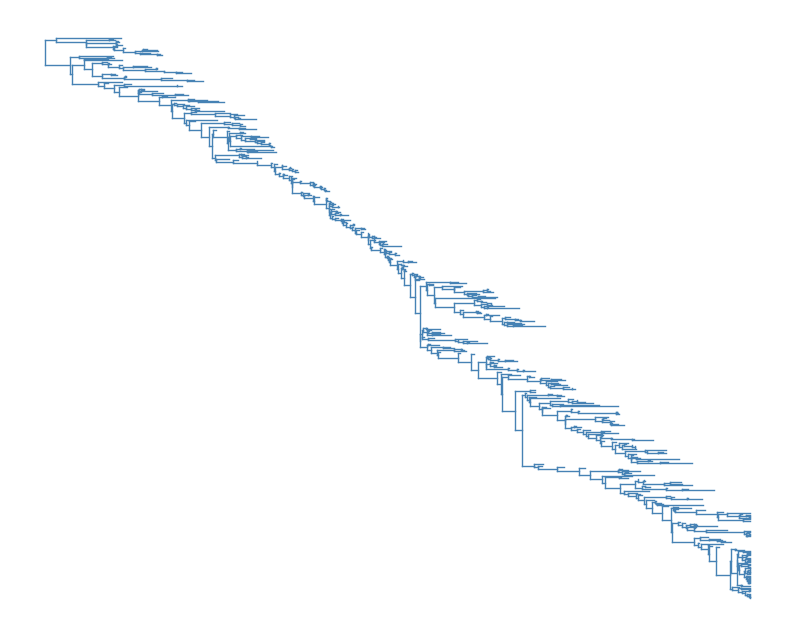

In [9]:
fig = plt.figure(figsize=(10, 8), facecolor="w")
options = {
    "showTaxa": False,
    "showIntervals": False,
    "showHeights": False,
    "branchWidth": 1.0,
}
draw_tree2(fig, tree_model.tree, **options)

## ADVI skyglide

In [11]:
elbo_samples_skyglide, elbos_skyglide = advi(tree_model, "skyglide")

  0%| ELBO: 0.000

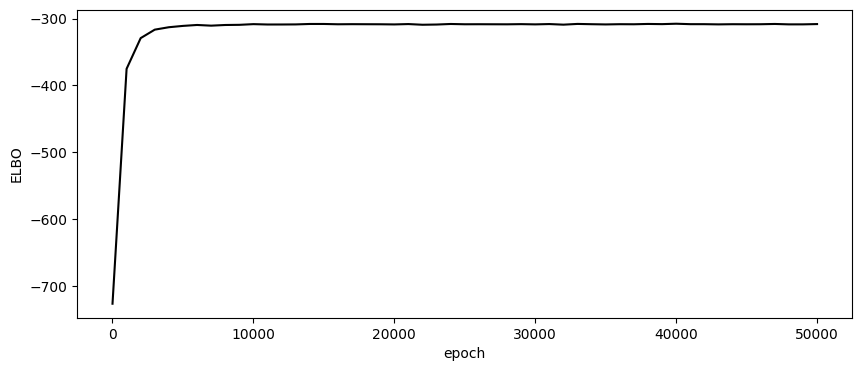

In [12]:
plt.plot(
    torch.arange(1, len(elbos_skyglide) * 1000, 1000).tolist(), elbos_skyglide, "k-"
)
plt.ylabel("ELBO")
plt.xlabel("epoch")
plt.show()

## HMC skyglide

In [13]:
hmc_samples_skyglide = hmc(tree_model, "skyglide")

  0%| Log prob: 0.000

operator 0.813 0.75 10000 0.10435990593928929


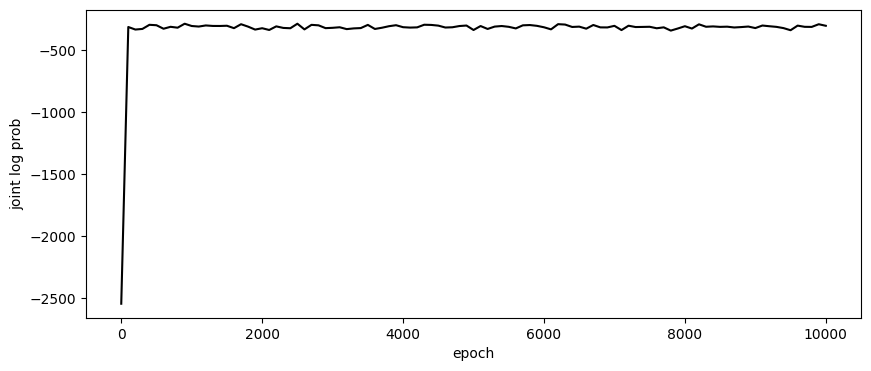

In [14]:
plt.plot(
    torch.arange(1, len(hmc_samples_skyglide) * 100, 100).tolist(),
    hmc_samples_skyglide[:, 0],
    "k-",
)
plt.ylabel("joint log prob")
plt.xlabel("epoch")
plt.show()

## ADVI skygrid

In [15]:
elbo_samples_skygrid, elbos_skygrid = advi(tree_model, "skygrid")

  0%| ELBO: 0.000

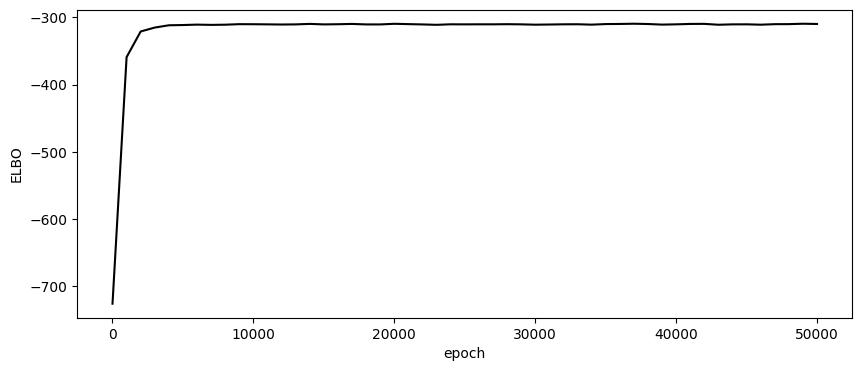

In [16]:
plt.plot(torch.arange(1, len(elbos_skygrid) * 1000, 1000).tolist(), elbos_skygrid, "k-")
plt.ylabel("ELBO")
plt.xlabel("epoch")
plt.show()

## HMC skygrid

In [17]:
hmc_samples_skygrid = hmc(tree_model, "skygrid")

  0%| Log prob: 0.000

operator 0.7914 0.81 10000 0.10028025434370283


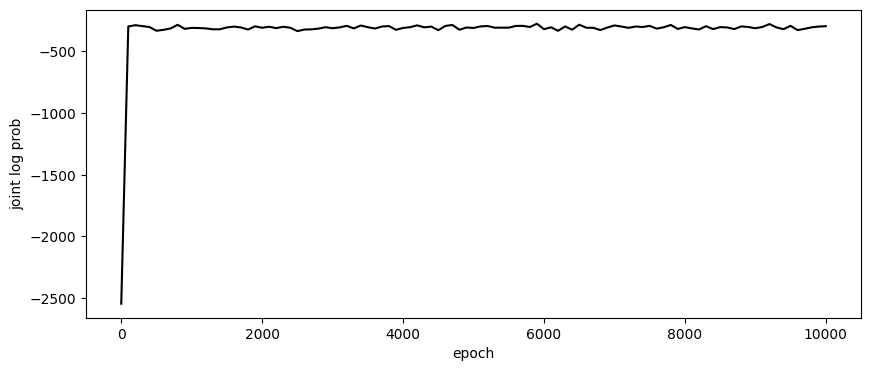

In [18]:
plt.plot(
    torch.arange(1, len(hmc_samples_skygrid) * 100, 100).tolist(),
    hmc_samples_skygrid[:, 0],
    "k-",
)
plt.ylabel("joint log prob")
plt.xlabel("epoch")
plt.show()

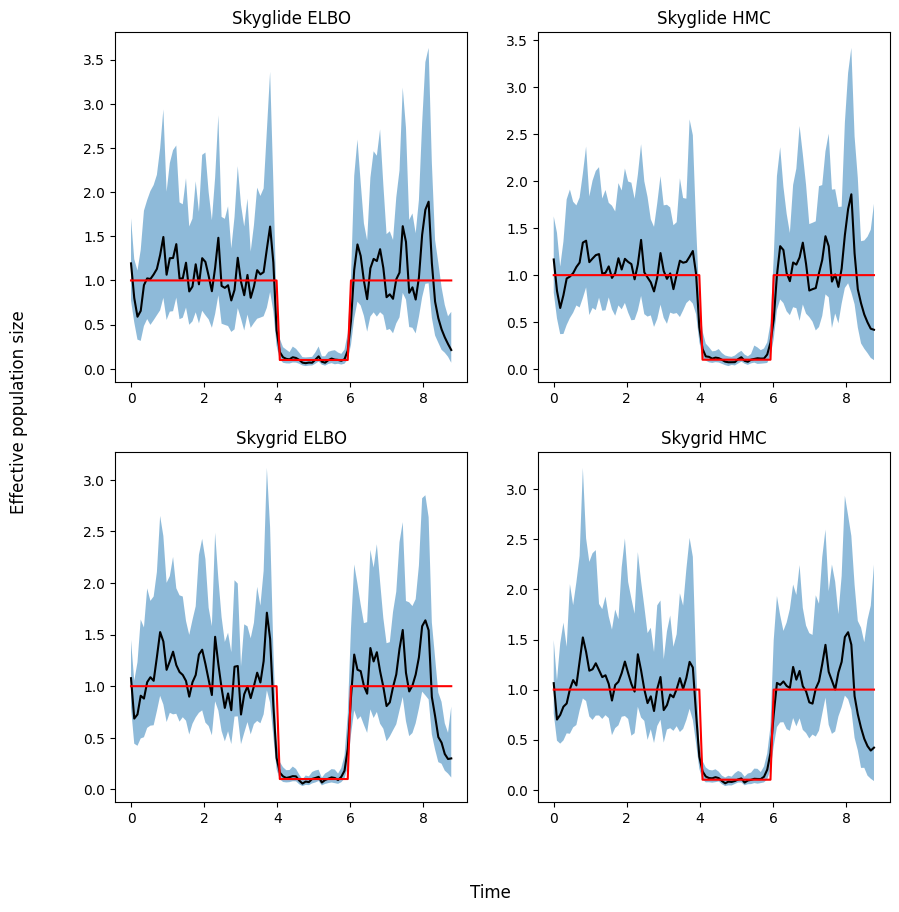

In [19]:
f, axes = plt.subplots(2, 2, figsize=(10, 10))
f.supxlabel("Time")
f.supylabel("Effective population size")
q = torch.tensor((0.025, 0.5, 0.975))
truetraj = bottleneck_traj(grid, ne_max=1.0, ne_min=0.1, bstart=6.0, bend=4.0)

quants = torch.quantile(elbo_samples_skyglide[:, 1:-1], q, 0)
axes[0, 0].plot(grid, quants[1], "k-")
axes[0, 0].plot(grid, truetraj, color="red")
axes[0, 0].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[0, 0].set_title("Skyglide ELBO")

burnin = len(hmc_samples_skyglide) // 10
quants = torch.quantile(hmc_samples_skyglide[burnin:, 1:-1], q, 0)
axes[0, 1].plot(grid, quants[1], "k-")
axes[0, 1].plot(grid, truetraj, color="red")
axes[0, 1].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[0, 1].set_title("Skyglide HMC")

quants = torch.quantile(elbo_samples_skygrid[:, 1:-1], q, 0)
axes[1, 0].plot(grid, quants[1], "k-")
axes[1, 0].plot(grid, truetraj, color="red")
axes[1, 0].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[1, 0].set_title("Skygrid ELBO")

burnin = len(hmc_samples_skygrid) // 10
quants = torch.quantile(hmc_samples_skygrid[burnin:, 1:-1], q, 0)
axes[1, 1].plot(grid, quants[1], "k-")
axes[1, 1].plot(grid, truetraj, color="red")
axes[1, 1].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[1, 1].set_title("Skygrid HMC")

# plt.savefig('sim-bottleneck.pdf')
plt.show()

# Constant trajectory

$N_e(0) = 1.0$

In [20]:
constant_traj = lambda t, ne_start: torch.full_like(t, ne_start)
tree_model = sample_phylogeny(500, 50, 8, constant_traj, ne_start=1.0)
grid = torch.linspace(0.0, tree_model.node_heights[-1], 100)

## ADVI skyglide

In [21]:
elbo_samples_skyglide_const, elbos_skyglide_cont = advi(tree_model, "skyglide")

  0%| ELBO: 0.000

## HMC skyglide

In [22]:
hmc_samples_skyglide_const = hmc(tree_model, "skyglide")

  0%| Log prob: 0.000

operator 0.4845 0.39 10000 0.0174696487382368


## ADVI skygrid

In [23]:
elbo_samples_skygrid_const, elbos_skygrid_const = advi(tree_model, "skygrid")

  0%| ELBO: 0.000

## HMC skygrid

In [24]:
hmc_samples_skygrid_const = hmc(tree_model, "skygrid")

  0%| Log prob: 0.000

operator 0.495 0.38 10000 0.015972274760265623


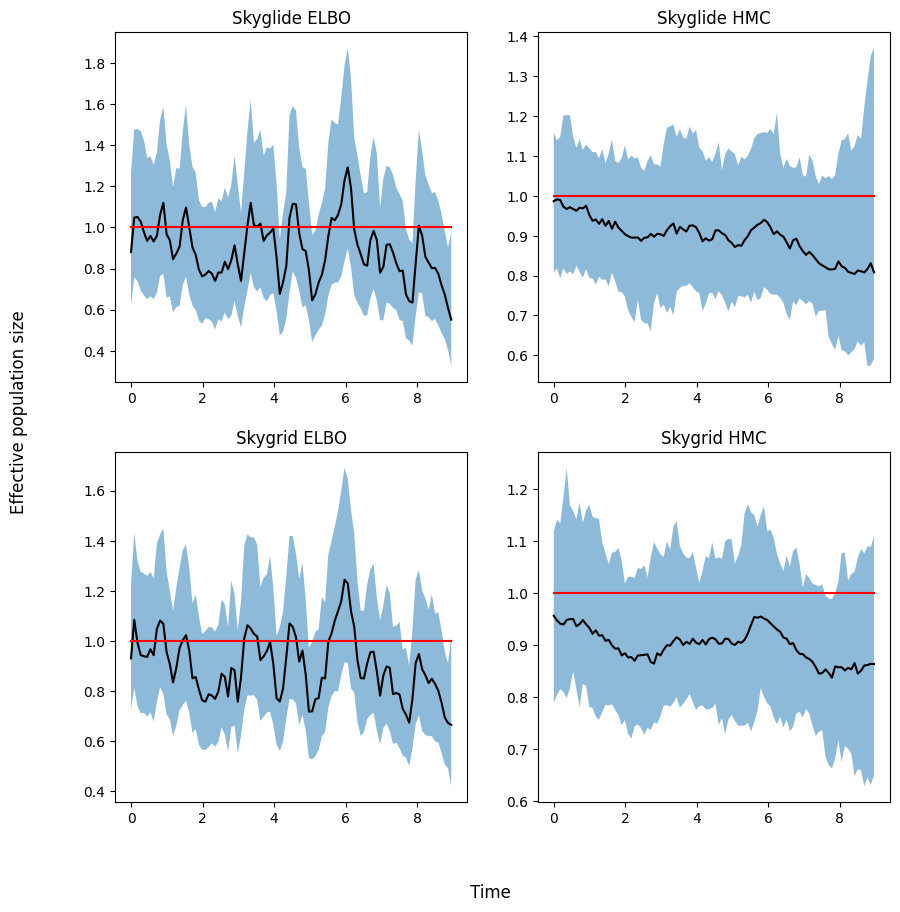

In [25]:
f, axes = plt.subplots(2, 2, figsize=(10, 10))
f.supxlabel("Time")
f.supylabel("Effective population size")
q = torch.tensor((0.025, 0.5, 0.975))
truetraj = constant_traj(grid, ne_start=1.0)

quants = torch.quantile(elbo_samples_skyglide_const[:, 1:-1], q, 0)
axes[0, 0].plot(grid, quants[1], "k-")
axes[0, 0].plot(grid, truetraj, color="red")
axes[0, 0].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[0, 0].set_title("Skyglide ELBO")

burnin = len(hmc_samples_skyglide_const) // 10
quants = torch.quantile(hmc_samples_skyglide_const[burnin:, 1:-1], q, 0)
axes[0, 1].plot(grid, quants[1], "k-")
axes[0, 1].plot(grid, truetraj, color="red")
axes[0, 1].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[0, 1].set_title("Skyglide HMC")

quants = torch.quantile(elbo_samples_skygrid_const[:, 1:-1], q, 0)
axes[1, 0].plot(grid, quants[1], "k-")
axes[1, 0].plot(grid, truetraj, color="red")
axes[1, 0].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[1, 0].set_title("Skygrid ELBO")

burnin = len(hmc_samples_skygrid_const) // 10
quants = torch.quantile(hmc_samples_skygrid_const[burnin:, 1:-1], q, 0)
axes[1, 1].plot(grid, quants[1], "k-")
axes[1, 1].plot(grid, truetraj, color="red")
axes[1, 1].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[1, 1].set_title("Skygrid HMC")

# plt.savefig('sim-constant.pdf')
plt.show()

# Linear trajectory

$N_e(0) = 0.1$ and the slope is defined such that $N_e(t_0) = 1.0$ where $t_0$ is the age of the root

In [26]:
def linear_traj(t, ne_start=1.0, slope=1.0):
    return t * slope + ne_start


tree_model = sample_phylogeny(
    500, 50, 8, linear_traj, ne_start=0.1, slope=(1.0 - 0.1) / grid[-1]
)
grid = torch.linspace(0.0, tree_model.node_heights[-1], 100)

## ADVI skyglide

In [27]:
elbo_samples_skyglide_linear, elbos_skyglide_linear = advi(tree_model, "skyglide")

  0%| ELBO: 0.000

## HMC skyglide

In [28]:
hmc_samples_skyglide_linear = hmc(tree_model, "skyglide")

  0%| Log prob: 0.000

operator 0.7122 0.86 10000 0.03651232450103821


## ADVI skygrid

In [29]:
elbo_samples_skygrid_linear, elbo_skygrid_linear = advi(tree_model, "skygrid")

  0%| ELBO: 0.000

## HMC skygrid

In [30]:
hmc_samples_skygrid_linear = hmc(tree_model, "skygrid")

  0%| Log prob: 0.000

operator 0.7031 0.8 10000 0.0365356035942702


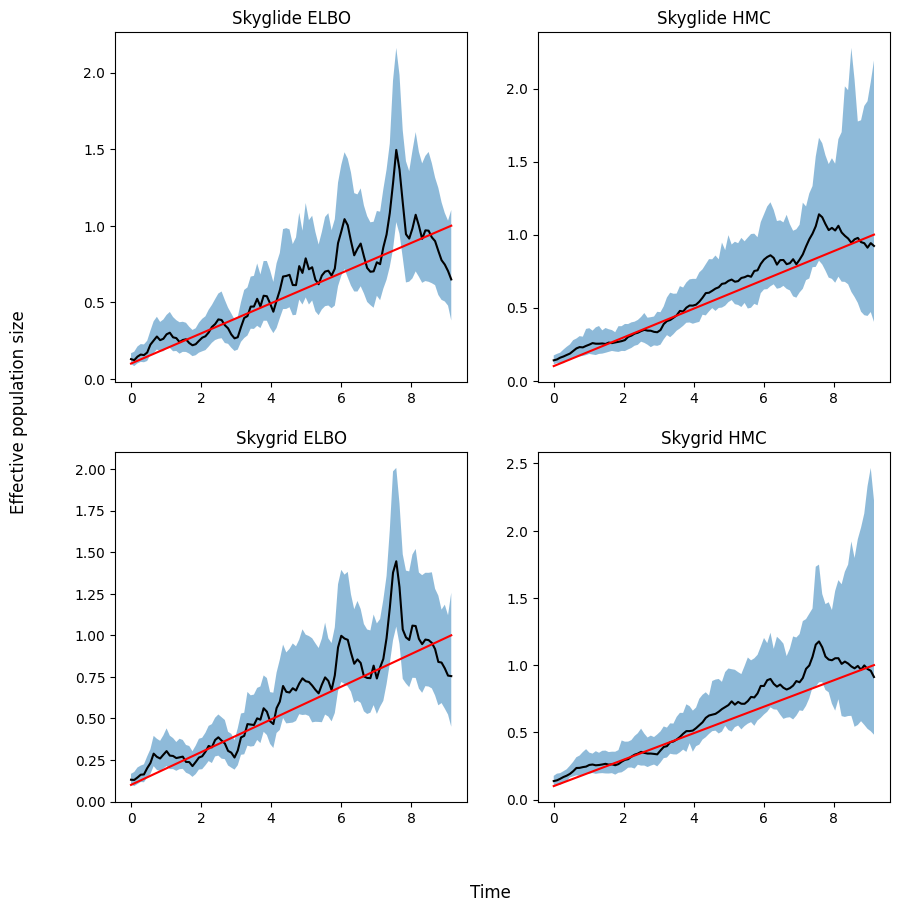

In [31]:
f, axes = plt.subplots(2, 2, figsize=(10, 10))
f.supxlabel("Time")
f.supylabel("Effective population size")
q = torch.tensor((0.025, 0.5, 0.975))
truetraj = linear_traj(grid, ne_start=0.1, slope=(1.0 - 0.1) / grid[-1])

quants = torch.quantile(elbo_samples_skyglide_linear[:, 1:-1], q, 0)
axes[0, 0].plot(grid, quants[1], "k-")
axes[0, 0].plot(grid, truetraj, color="red")
axes[0, 0].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[0, 0].set_title("Skyglide ELBO")

burnin = len(hmc_samples_skyglide_linear) // 10
quants = torch.quantile(hmc_samples_skyglide_linear[burnin:, 1:-1], q, 0)
axes[0, 1].plot(grid, quants[1], "k-")
axes[0, 1].plot(grid, truetraj, color="red")
axes[0, 1].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[0, 1].set_title("Skyglide HMC")

quants = torch.quantile(elbo_samples_skygrid_linear[:, 1:-1], q, 0)
axes[1, 0].plot(grid, quants[1], "k-")
axes[1, 0].plot(grid, truetraj, color="red")
axes[1, 0].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[1, 0].set_title("Skygrid ELBO")

burnin = len(hmc_samples_skygrid_linear) // 10
quants = torch.quantile(hmc_samples_skygrid_linear[burnin:, 1:-1], q, 0)
axes[1, 1].plot(grid, quants[1], "k-")
axes[1, 1].plot(grid, truetraj, color="red")
axes[1, 1].fill_between(grid, quants[0], quants[2], alpha=0.5)
axes[1, 1].set_title("Skygrid HMC")

# plt.savefig('sim-linear.pdf')
plt.show()